# Step 1.1 — Preprocessing

This notebook is the preprocessing stage of the project. Every subsequent step (mass extraction in Step 1.2, background-patch sampling in Step 1.3, and feature extraction / classification in Steps 2.1–2.4) reads from the `.npy` files this notebook saves.

For each of the 410 INbreast DICOMs the pipeline:

1. **Normalises** the pixel array to `[0, 1]` using a 1st/99th-percentile clip (see "Differences from the paper" below).
2. **Removes the pectoral muscle** on MLO/ML views using the ground-truth LabelMe JSON polygons from Aliniya 2023 (the source audited in Step 0.3).
3. **Builds a breast mask** via Otsu thresholding → morphological close/open → largest connected component → fill holes.
4. **Applies CLAHE** inside the breast mask for local contrast enhancement (`clipLimit=2.0`, `tileGridSize=(8, 8)`).

What gets saved (Section 6 below):

- `data/outputs/preprocessed/final/<stem>.npy` — final preprocessed image (float32, `[0, 1]`, background = 0).
- `data/outputs/preprocessed/breast_mask/<stem>.npy` — uint8 binary breast mask.
- `data/outputs/preprocessed/pect_mask/<stem>.npy` — uint8 binary pectoral mask (all-zeros for CC views and the 4 MLO/ML views without a LabelMe JSON).
- `data/outputs/preprocessed/preproc_index.csv` — one-row-per-DICOM manifest used by every downstream stage.

## Differences from the reference paper (Razali et al. 2023)

1. We do not convert the DICOMs to PNG; we operate directly on the float pixel array.
2. **Normalisation:** 1st/99th-percentile clip + rescale to [0, 1]. The paper applies a plain min-max scaling after converting DICOM → PNG; we tested raw min-max on these mammograms as an ablation (`norm_mode="minmax"`) and found that a few extreme pixels (calibration markers, edge artefacts, sensor hot spots) compress the meaningful breast-tissue range into a narrow band near zero, dropping 10-fold CV accuracy from ~83% to ~80%. The percentile clip is robust to those outliers. This is a small implementation adaptation, not a methodological change. Earlier versions of the loader also applied a VOI LUT and inverted MONOCHROME1 images defensively; a header audit (Step 0.1) showed that all 410 INbreast files are MONOCHROME2 with no VOI LUT data, so both branches were no-ops on this dataset and have been removed.
3. **Background removal:** the paper sets the background to `NaN` (MATLAB convention); we use a binary breast mask and set the background to `0`. Functionally equivalent because the downstream patch sampler never samples outside the breast mask.
4. **Pectoral muscle removal:** the paper uses seeded region growing on MLO views; we use ground-truth LabelMe polygon masks from a public release (Aliniya 2023). A supervised mask source is at least as reliable as a heuristic region-growing step and avoids tuning a per-image seed.
5. **Contrast enhancement:** the paper uses a density-aware histogram adjustment by the same authors; we use standard CLAHE, which is density-agnostic and likely contributes to the small replication gap on the WS-only tissue task.


## 1. Setup — paths, dependencies, and file collection

The first code cell installs `opencv-python` and `scipy` (CLAHE in Section 5 and the breast-mask morphology in Section 5 depend on them). The second code cell sets the project-relative paths to the DICOM and pectoral-mask folders, collects every `.dcm` and matching LabelMe `.json`, builds a stem-keyed lookup, and prints how many of the 410 DICOMs have a matching pectoral-mask JSON. Section 4 picks one matched image and shows the first sanity-check preview.


In [1]:
%pip install opencv-python scipy

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pydicom
import matplotlib.pyplot as plt
import cv2

SEED = 34  # project-wide seed for the example/preview image picks in this notebook

# ---- EDIT THESE PATHS ----
DICOM_DIR = Path("../data/raw/inbreast/ALL-IMGS")
MASK_DIR  = Path("../data/raw/muscle_masks_for_raw_data")  # where you copied the JSON masks
# -------------------------

# Collect files
dicoms = sorted(DICOM_DIR.glob("*.dcm"))

# ignore Windows "Zone.Identifier" garbage if present
json_masks = [p for p in MASK_DIR.rglob("*.json") if "Zone.Identifier" not in p.name]

print("DICOMs:", len(dicoms))
print("JSON masks:", len(json_masks))

mask_by_stem = {p.stem: p for p in json_masks}

matched = [p for p in dicoms if p.stem in mask_by_stem]
print("DICOMs with a matching JSON mask:", len(matched))

if len(matched) == 0:
    # helpful debugging: show example stems
    print("\nExample DICOM stems:", [p.stem for p in dicoms[:5]])
    print("Example MASK stems:", [p.stem for p in json_masks[:5]])
    raise RuntimeError("No matches found. Likely different naming scheme between your DICOMs and the mask JSONs.")


DICOMs: 410
JSON masks: 202
DICOMs with a matching JSON mask: 202


## 2. Coverage report — which DICOMs have a pectoral mask

Before running the full pipeline I tabulate how many DICOMs have a matching LabelMe JSON pectoral mask, broken down by view. The pectoral-removal step in Section 4 is gated on view ∈ {MLO, ML} AND mask-present, so this table is what tells me how many files will silently skip that step.


In [2]:
from pathlib import Path
import re
import pandas as pd

DICOM_DIR = Path("../data/raw/inbreast/ALL-IMGS")
MASK_DIR  = Path("../data/raw/muscle_masks_for_raw_data")  # where your JSONs live

dicoms = sorted(DICOM_DIR.glob("*.dcm"))
json_masks = [p for p in MASK_DIR.rglob("*.json") if "Zone.Identifier" not in p.name]

print("DICOMs:", len(dicoms))
print("JSON masks:", len(json_masks))

mask_by_stem = {p.stem: p for p in json_masks}

rows = []
for d in dicoms:
    u = d.name.upper()
    view = "MLO" if "_MLO_" in u else ("CC" if "_CC_" in u else ("ML" if "_ML_" in u else "UNK"))
    lat  = "R" if "_R_" in u else ("L" if "_L_" in u else "UNK")
    rows.append({
        "stem": d.stem,
        "dicom": str(d),
        "view": view,
        "laterality": lat,
        "has_pect_json": d.stem in mask_by_stem,
        "pect_json": str(mask_by_stem[d.stem]) if d.stem in mask_by_stem else None,
    })

cov = pd.DataFrame(rows)
display(cov["has_pect_json"].value_counts())
display(cov.groupby(["view","has_pect_json"]).size().unstack(fill_value=0))

DICOMs: 410
JSON masks: 202


has_pect_json
False    208
True     202
Name: count, dtype: int64

has_pect_json,False,True
view,,
CC,202,1
ML,5,201
UNK,1,0


### What the coverage table tells us

- 410 DICOMs in total, 202 with a matching LabelMe JSON pectoral mask.
- Of the 206 MLO/ML views, **202 have a pectoral mask and 4 do not** (5 with view `ML` no-mask, 1 with view `UNK`). These 4 silently skip the pectoral step — the (small) pectoral region remains inside the breast mask. Step 0.3 audits this further: 5 of the 206 file_ids differ between the two public pectoral-mask sources (3 only in our GitHub set, 2 only in the Kaggle XML set), so there is a small irreducible gap on either side.
- **1 CC view also has a JSON polygon**: `50994273`, audited in Step 0.3. CC views technically do not contain pectoral muscle, but the GitHub annotator drew a thin sliver here that the original Porto annotators did not. The pipeline's view-gating (`is_oblique`) means this CC mask is **not** applied (CC views skip the pectoral step regardless), so this anomaly has no downstream effect.
- The 1 `UNK` filename is one whose view marker the regex couldn't classify; it's flagged so it stays visible in the table but processed normally.


## 3. Helpers — DICOM loader and JSON-polygon → mask

The next code cell defines the two helpers used by every subsequent section: `load_dicom_norm` and `labelme_json_to_mask`. These are the single source of truth — the per-image pipeline in Section 5 calls them, the preview in Section 4 calls them, and the case-walkthrough in Section 9 deliberately redefines its own variant (see the note in Section 9).

**Normalisation.** `load_dicom_norm` clips each DICOM at the 1st/99th percentile of its own pixel distribution and rescales to [0, 1]. The reference paper uses a plain min-max stretch after DICOM → PNG conversion; we tested this on INbreast (`norm_mode="minmax"`) and found that a small number of outlier pixels (calibration markers, edge artefacts, sensor hot spots) pull the max far above the bulk tissue distribution and compress real breast pixels into a narrow band near zero. The percentile clip is robust to that and keeps the breast-tissue dynamic range well-spread across [0, 1] (~83% vs ~80% 10-fold CV accuracy on the tissue task). This is a small implementation adaptation, not a methodological change. The loader does not apply a VOI LUT or invert MONOCHROME1 images: a header audit (Step 0.1) confirmed all 410 INbreast files are MONOCHROME2 with no VOI LUT data, so the earlier defensive branches did nothing on this dataset and have been removed.


In [3]:
import json
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import cv2

def load_dicom_norm(path: Path, norm_mode: str = "percentile") -> np.ndarray:
    """
    Read a DICOM and normalise pixel values to [0, 1].

    Parameters
    ----------
    path : Path
        Path to DICOM file.
    norm_mode : str, {"percentile", "minmax"}
        "percentile" — clip at 1st / 99th percentile then rescale
                       (default).  The paper uses a plain min-max
                       stretch after DICOM → PNG conversion; we use
                       a percentile clip because a small number of
                       outlier pixels in INbreast (markers, edge
                       artefacts, hot pixels) would otherwise compress
                       real breast tissue into a narrow band near zero.
                       The ablation that documents this is `norm_mode=
                       "minmax"` (below).
        "minmax"     — simple (img - min) / (max - min); kept for the
                       ablation only.

    Note: VOI LUT application and MONOCHROME1 inversion are not
    performed.  All 410 INbreast files are MONOCHROME2 with no VOI
    LUT data (audited in Step 0.1), so both branches were no-ops on
    this dataset and have been removed.
    """
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)

    # --- normalise to [0, 1] ---
    if norm_mode == "minmax":
        lo, hi = float(img.min()), float(img.max())
    elif norm_mode == "percentile":
        lo, hi = np.percentile(img, (1, 99))
        img = np.clip(img, lo, hi)
    else:
        raise ValueError(f"Unknown norm_mode: {norm_mode!r}")

    img = (img - lo) / (hi - lo + 1e-8)
    return img

def labelme_json_to_mask(json_path: Path, shape_hw: tuple[int,int]) -> np.ndarray:
    """Fill all polygons in LabelMe-style JSON into a binary mask."""
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)

    with open(json_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    shapes = ann.get("shapes", [])
    for s in shapes:
        pts = np.array(s.get("points", []), dtype=np.float32)
        if pts.size == 0:
            continue
        pts = np.round(pts).astype(np.int32)
        pts[:, 0] = np.clip(pts[:, 0], 0, W - 1)
        pts[:, 1] = np.clip(pts[:, 1], 0, H - 1)
        cv2.fillPoly(mask, [pts], 1)

    return mask

## 4. Pectoral-mask overlay preview

Now that the helpers from Section 3 are defined, pick one matched MLO image at random and show a 3-panel quick-look: normalised DICOM, the LabelMe polygon mask overlaid, and the pectoral region zeroed out. This is the first visual confirmation that the paths are right and the JSON polygons actually line up with the DICOMs.


**Reproducibility.** The preview cells in this notebook pick example images at random; they are seeded with the project-wide `SEED = 34` (`random.Random(SEED)`), so the same example/overlay images appear on every run. The preprocessing itself runs over *all* images deterministically and does not depend on this seed.


Example:
DICOM: 50997080_ce5e5e18a261cd29_MG_L_ML_ANON.dcm
MASK : 50997080_ce5e5e18a261cd29_MG_L_ML_ANON.json
Image shape: (3328, 2560) | Mask sum: 153730


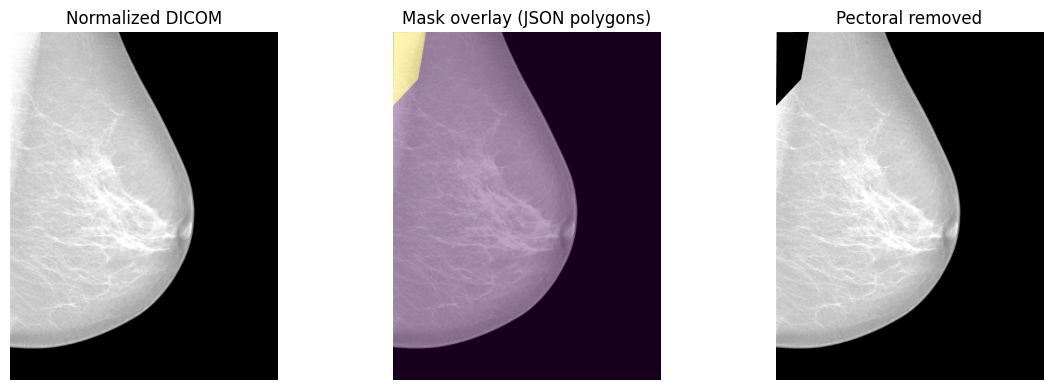

In [4]:
# Pick a random matched image (prefer MLO/ML if available).  `load_dicom_norm`
# and `labelme_json_to_mask` come from Section 3.
def looks_like_mlo(name: str) -> bool:
    u = name.upper()
    return ("_MLO_" in u) or ("_ML_" in u)

mlo_matched = [p for p in matched if looks_like_mlo(p.name)]
dicom_path = random.Random(SEED).choice(mlo_matched if mlo_matched else matched)
mask_path = mask_by_stem[dicom_path.stem]

img = load_dicom_norm(dicom_path)
mask = labelme_json_to_mask(mask_path, img.shape)

# Apply mask (remove pectoral)
img_no_pect = img.copy()
img_no_pect[mask == 1] = 0.0

print("\nExample:")
print("DICOM:", dicom_path.name)
print("MASK :", mask_path.name)
print("Image shape:", img.shape, "| Mask sum:", int(mask.sum()))

# Show side-by-side
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Normalized DICOM")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img, cmap="gray")
plt.imshow(mask, alpha=0.35)
plt.title("Mask overlay (JSON polygons)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_no_pect, cmap="gray")
plt.title("Pectoral removed")
plt.axis("off")

plt.tight_layout()
plt.show()


## 5. Breast mask, CLAHE, and the full pipeline function

The next cell defines:

- `to_uint8` — convert a `[0, 1]` float array to the 8-bit form OpenCV's CLAHE expects.
- `make_breast_mask` — Otsu threshold + morphology (close/open with an 11-pixel elliptical kernel) + largest connected component + fill holes. This produces the binary breast mask saved to `data/outputs/preprocessed/breast_mask/`.
- `apply_clahe` — CLAHE applied inside the breast mask only, so the background stays at zero.
- `preprocess_one(dicom_path)` — the one-DICOM end-to-end function used by both the single-image preview (Section 6) and the batch save (Section 7). Returns a dict of every intermediate image so the preview plot can show each pipeline stage.


In [5]:
from scipy import ndimage as ndi

def to_uint8(img01: np.ndarray) -> np.ndarray:
    return (np.clip(img01, 0, 1) * 255).astype(np.uint8)

def make_breast_mask(img01: np.ndarray) -> np.ndarray:
    """
    Segment breast vs background:
    - Otsu threshold on normalized image
    - morphology cleanup
    - keep largest component
    - fill holes
    """
    u8 = to_uint8(img01)
    _, m = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=2)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k, iterations=1)

    num, labels = cv2.connectedComponents(m)
    if num <= 1:
        mask = (m > 0).astype(np.uint8)
    else:
        sizes = [(labels == i).sum() for i in range(1, num)]
        biggest = 1 + int(np.argmax(sizes))
        mask = (labels == biggest).astype(np.uint8)

    mask = ndi.binary_fill_holes(mask).astype(np.uint8)
    return mask

def apply_clahe(img01: np.ndarray, mask: np.ndarray, clip=2.0, tiles=(8,8)) -> np.ndarray:
    u8 = to_uint8(img01)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tiles)
    enh = clahe.apply(u8).astype(np.float32) / 255.0
    return enh * mask.astype(np.float32)

def preprocess_one(dicom_path: Path, do_contrast=True):
    """
    Returns a dict of intermediate + final images/masks (all numpy arrays).
    """
    norm = load_dicom_norm(dicom_path)

    # Pectoral removal ONLY if we have a matching JSON (and only for oblique-ish views)
    u = dicom_path.name.upper()
    is_oblique = ("_MLO_" in u) or ("_ML_" in u)

    pect_mask = np.zeros_like(norm, dtype=np.uint8)
    if is_oblique and dicom_path.stem in mask_by_stem:
        pect_mask = labelme_json_to_mask(mask_by_stem[dicom_path.stem], norm.shape)

    no_pect = norm.copy()
    no_pect[pect_mask == 1] = 0.0

    # Breast mask after pectoral removal (usually cleaner)
    breast_mask = make_breast_mask(no_pect)

    bg_removed = no_pect * breast_mask.astype(np.float32)

    final = apply_clahe(bg_removed, breast_mask) if do_contrast else bg_removed

    return {
        "norm": norm,
        "pect_mask": pect_mask,
        "no_pect": no_pect,
        "breast_mask": breast_mask,
        "bg_removed": bg_removed,
        "final": final,
    }

## 6. Single-image pipeline preview

A six-panel plot for one random MLO image showing every stage of `preprocess_one` in order: normalised → pectoral-mask overlay → pectoral removed → breast mask → background removed → final (CLAHE). If anything is going to look wrong, it's most visible here before committing to the 4-minute batch save.


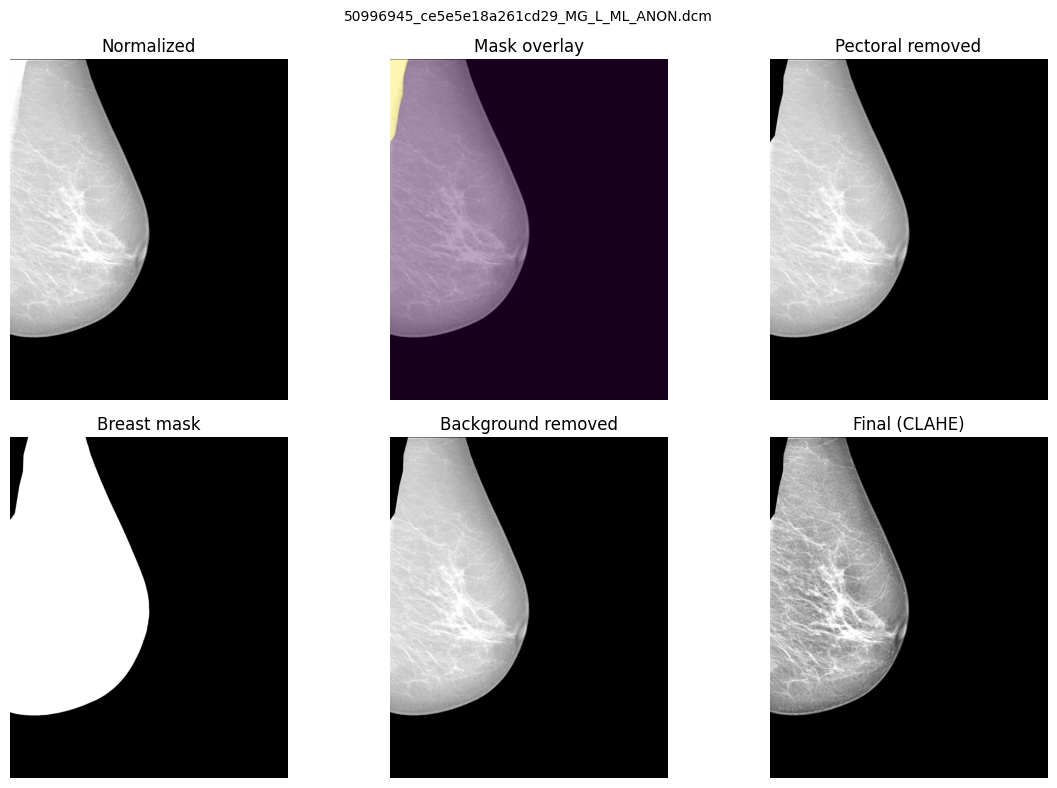

In [6]:
import random
import matplotlib.pyplot as plt

mlo_like = [Path(r["dicom"]) for r in rows if r["view"] in ("MLO","ML")]
p = random.Random(SEED).choice(mlo_like if mlo_like else dicoms)

out = preprocess_one(p, do_contrast=True)

plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.imshow(out["norm"], cmap="gray"); plt.title("Normalized"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(out["norm"], cmap="gray"); plt.imshow(out["pect_mask"], alpha=0.35); plt.title("Mask overlay"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(out["no_pect"], cmap="gray"); plt.title("Pectoral removed"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(out["breast_mask"], cmap="gray"); plt.title("Breast mask"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(out["bg_removed"], cmap="gray"); plt.title("Background removed"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(out["final"], cmap="gray"); plt.title("Final (CLAHE)"); plt.axis("off")
plt.suptitle(p.name, fontsize=10)
plt.tight_layout()
plt.show()

## 7. Batch preprocess and save to `data/outputs/preprocessed/`

The cell below runs `preprocess_one` over all 410 DICOMs and saves three `.npy` arrays per image plus a one-row-per-DICOM manifest CSV. This is the cell that produces the data product every later notebook reads. The whole loop takes roughly five minutes on a laptop and is deterministic — re-running it produces byte-identical files.


In [7]:
import os
from tqdm import tqdm
import pandas as pd
import numpy as np

OUT_DIR = Path("../data/outputs/preprocessed")
(OUT_DIR / "final").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "breast_mask").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "pect_mask").mkdir(parents=True, exist_ok=True)

index_rows = []

for d in tqdm(dicoms, total=len(dicoms)):
    o = preprocess_one(d, do_contrast=True)

    stem = d.stem
    final_path = OUT_DIR / "final" / f"{stem}.npy"
    bmask_path = OUT_DIR / "breast_mask" / f"{stem}.npy"
    pmask_path = OUT_DIR / "pect_mask" / f"{stem}.npy"

    np.save(final_path, o["final"].astype(np.float32))
    np.save(bmask_path, o["breast_mask"].astype(np.uint8))
    np.save(pmask_path, o["pect_mask"].astype(np.uint8))

    u = d.name.upper()
    view = "MLO" if "_MLO_" in u else ("CC" if "_CC_" in u else ("ML" if "_ML_" in u else "UNK"))
    lat  = "R" if "_R_" in u else ("L" if "_L_" in u else "UNK")

    index_rows.append({
        "stem": stem,
        "dicom": str(d),
        "final_npy": str(final_path),
        "breast_mask_npy": str(bmask_path),
        "pect_mask_npy": str(pmask_path),
        "view": view,
        "laterality": lat,
        "has_pect_json": int(o["pect_mask"].sum() > 0),
        "pect_json": str(mask_by_stem[stem]) if stem in mask_by_stem else None,
    })

index_df = pd.DataFrame(index_rows)
index_csv = OUT_DIR / "preproc_index.csv"
index_df.to_csv(index_csv, index=False)
print("Saved:", index_csv)
display(index_df.head())

  0%|          | 0/410 [00:00<?, ?it/s]

100%|██████████| 410/410 [04:21<00:00,  1.57it/s]


Saved: ../data/outputs/preprocessed/preproc_index.csv


,stem,dicom,final_npy,breast_mask_npy,pect_mask_npy,view,laterality,has_pect_json,pect_json
0,20586908_6c613a14b80a8591_MG_R_CC_ANON,../data/raw/inbreast/ALL-IMGS/20586908_6c613a1...,../data/outputs/preprocessed/final/20586908_6c61...,../data/outputs/preprocessed/breast_mask/2058690...,../data/outputs/preprocessed/pect_mask/20586908_...,CC,R,0,NaN
1,20586934_6c613a14b80a8591_MG_L_CC_ANON,../data/raw/inbreast/ALL-IMGS/20586934_6c613a1...,../data/outputs/preprocessed/final/20586934_6c61...,../data/outputs/preprocessed/breast_mask/2058693...,../data/outputs/preprocessed/pect_mask/20586934_...,CC,L,0,NaN
2,20586960_6c613a14b80a8591_MG_R_ML_ANON,../data/raw/inbreast/ALL-IMGS/20586960_6c613a1...,../data/outputs/preprocessed/final/20586960_6c61...,../data/outputs/preprocessed/breast_mask/2058696...,../data/outputs/preprocessed/pect_mask/20586960_...,ML,R,1,../data/raw/muscle_masks_for_raw_data/20586960...
3,20586986_6c613a14b80a8591_MG_L_ML_ANON,../data/raw/inbreast/ALL-IMGS/20586986_6c613a1...,../data/outputs/preprocessed/final/20586986_6c61...,../data/outputs/preprocessed/breast_mask/2058698...,../data/outputs/preprocessed/pect_mask/20586986_...,ML,L,1,../data/raw/muscle_masks_for_raw_data/20586986...
4,20587054_b6a4f750c6df4f90_MG_R_CC_ANON,../data/raw/inbreast/ALL-IMGS/20587054_b6a4f75...,../data/outputs/preprocessed/final/20587054_b6a4...,../data/outputs/preprocessed/breast_mask/2058705...,../data/outputs/preprocessed/pect_mask/20587054_...,CC,R,0,NaN


### What was saved

For each of the 410 DICOMs the cell wrote three `.npy` arrays and one row of `preproc_index.csv`:

- `final/<stem>.npy` — float32 in `[0, 1]`, background zeroed. The canonical preprocessed image used by every downstream notebook.
- `breast_mask/<stem>.npy` — uint8 binary mask of the segmented breast.
- `pect_mask/<stem>.npy` — uint8 binary mask of the pectoral region (all zeros for CC views and for the 4 MLO/ML views without a LabelMe JSON).
- One row of `preproc_index.csv` with the file_id stem, the original DICOM path, the three `.npy` paths, the view/laterality parsed from the filename, and a `has_pect_json` flag.

`preproc_index.csv` is the manifest that Steps 1.2, 1.3, 2.1, 2.2, 2.3 and 2.4 all read to enumerate the dataset.


## 8. Post-save verification — spot-check 5 random saved files

A quick spot-check that the batch save actually wrote what we expected. The cell loads five random saved files (seeded so the same five are picked on every run) and prints dtype/shape/value-range for each, plus a 4-panel plot per file: the final image, the final + breast-mask overlay, the final + pectoral-mask overlay, and a 2-colour composite of the two masks (breast = green, pectoral = red).


stem: 50996972_ce5e5e18a261cd29_MG_R_ML_ANON
final: float32 (4084, 3328) min=0.0000 max=1.0000 mean=0.1999
breast_mask: uint8 (4084, 3328) sum: 4219387 frac: 0.310441883311045
pect_mask: uint8 (4084, 3328) sum: 468418 frac: 0.034463908168839


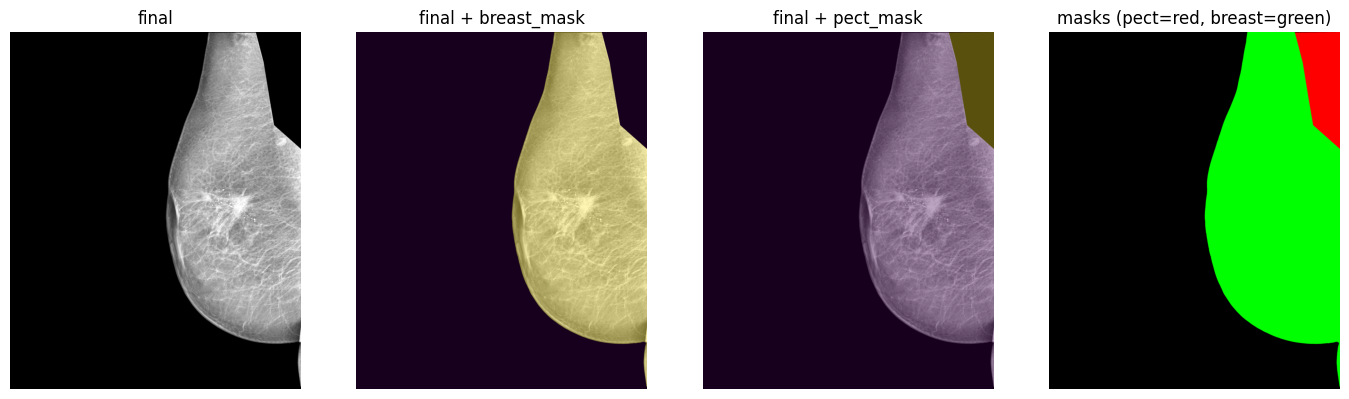

stem: 24065611_d8205a09c8173f44_MG_R_CC_ANON
final: float32 (3328, 2560) min=0.0000 max=1.0000 mean=0.1889
breast_mask: uint8 (3328, 2560) sum: 2415471 frac: 0.2835166344275841
pect_mask: uint8 (3328, 2560) sum: 0 frac: 0.0


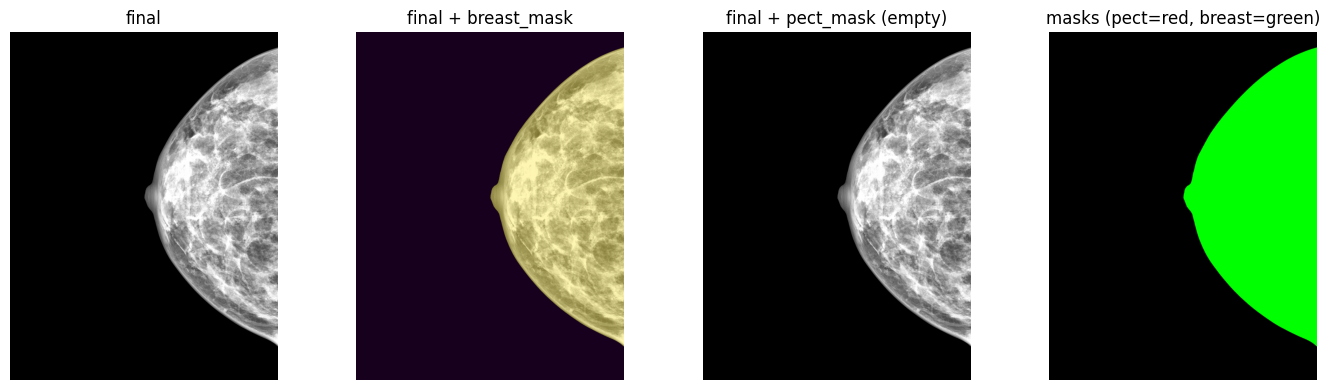

stem: 50998231_f34ee0ab6591b792_MG_L_CC_ANON
final: float32 (4084, 3328) min=0.0000 max=1.0000 mean=0.2092
breast_mask: uint8 (4084, 3328) sum: 3968042 frac: 0.2919491460577865
pect_mask: uint8 (4084, 3328) sum: 0 frac: 0.0


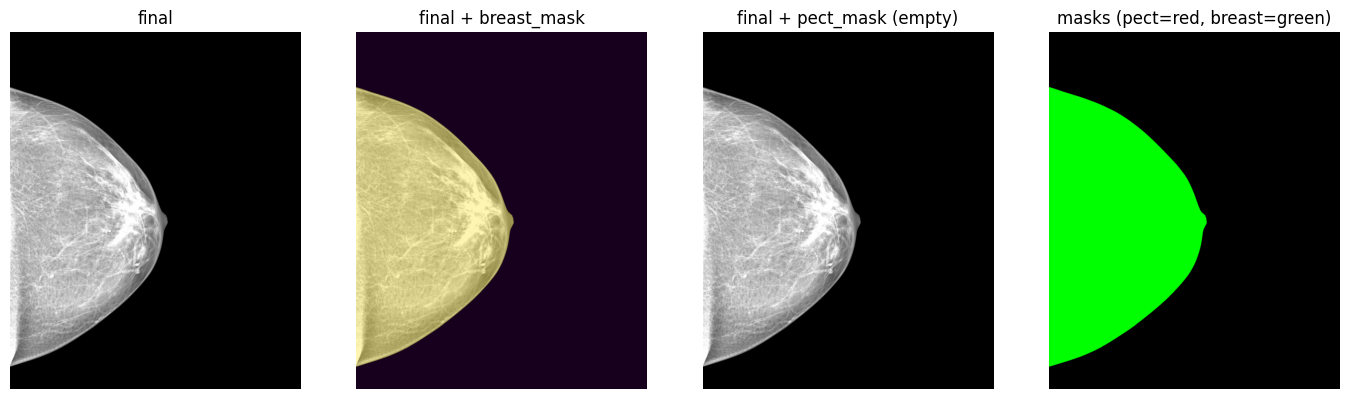

stem: 20587466_d571b5880ad2a016_MG_L_CC_ANON
final: float32 (3328, 2560) min=0.0000 max=1.0000 mean=0.1174
breast_mask: uint8 (3328, 2560) sum: 1428465 frac: 0.16766650860126203
pect_mask: uint8 (3328, 2560) sum: 0 frac: 0.0


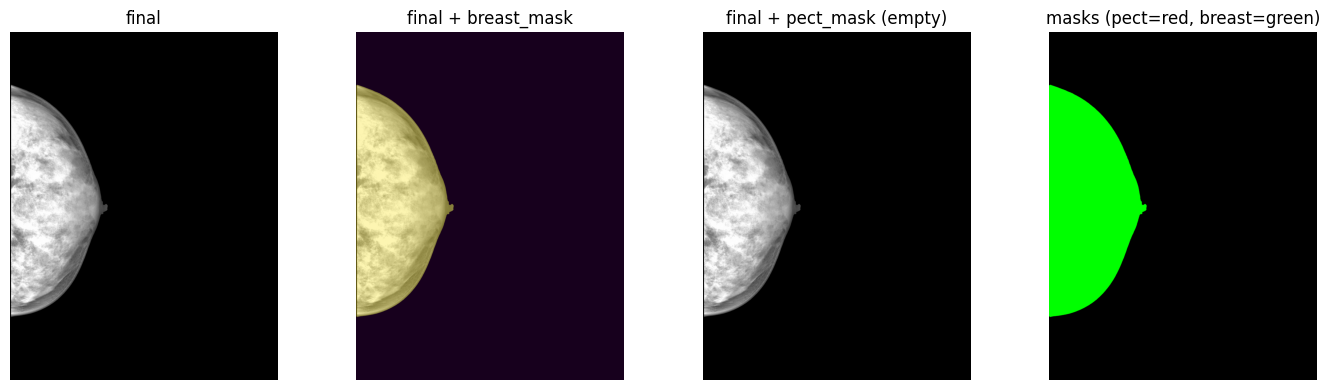

stem: 22670703_e15a16f87b4f9782_MG_L_ML_ANON
final: float32 (4084, 3328) min=0.0000 max=1.0000 mean=0.2146
breast_mask: uint8 (4084, 3328) sum: 4753415 frac: 0.3497330547681383
pect_mask: uint8 (4084, 3328) sum: 534313 frac: 0.03931214036483839


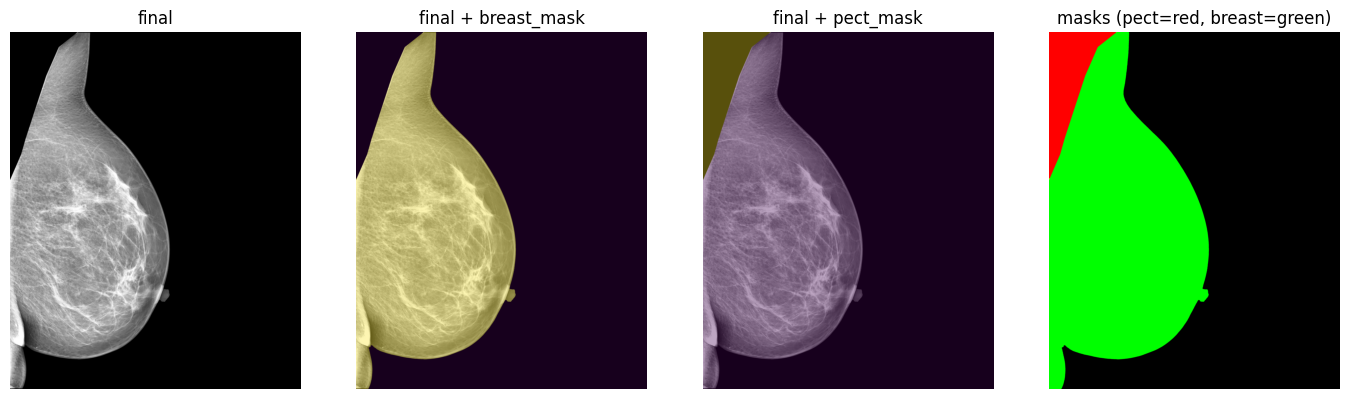

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("../data/outputs/preprocessed")  # change if needed

final_dir = OUT_DIR / "final"
bmask_dir = OUT_DIR / "breast_mask"
pmask_dir = OUT_DIR / "pect_mask"

final_files = sorted(final_dir.glob("*.npy"))
assert final_files, f"No .npy files found in {final_dir.resolve()}"

k = min(5, len(final_files))
samples = random.Random(SEED).sample(final_files, k=k)

for p in samples:
    stem = p.stem

    final = np.load(final_dir / f"{stem}.npy")
    bmask = np.load(bmask_dir / f"{stem}.npy")
    pmask = np.load(pmask_dir / f"{stem}.npy")

    print("=" * 60)
    print("stem:", stem)
    print("final:", final.dtype, final.shape, f"min={final.min():.4f}", f"max={final.max():.4f}", f"mean={final.mean():.4f}")
    print("breast_mask:", bmask.dtype, bmask.shape, "sum:", int(bmask.sum()), "frac:", float(bmask.mean()))
    print("pect_mask:", pmask.dtype, pmask.shape, "sum:", int(pmask.sum()), "frac:", float(pmask.mean()))

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(final, cmap="gray")
    plt.title("final")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(final, cmap="gray")
    plt.imshow(bmask, alpha=0.35)
    plt.title("final + breast_mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(final, cmap="gray")
    if pmask.sum() > 0:
        plt.imshow(pmask, alpha=0.35)
        plt.title("final + pect_mask")
    else:
        plt.title("final + pect_mask (empty)")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    # show just the masks side-by-side via RGB composite (breast=green, pect=red)
    comp = np.zeros((*final.shape, 3), dtype=np.float32)
    comp[..., 1] = bmask.astype(np.float32)  # green
    comp[..., 0] = pmask.astype(np.float32)  # red
    plt.imshow(comp)
    plt.title("masks (pect=red, breast=green)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### What the verification cell shows

For each of the five sampled files the print-out confirms:

- `final.dtype == float32` and the value range is roughly `[0, 1]` (CLAHE is applied inside the breast mask, background stays at zero).
- `breast_mask.dtype == uint8`, `sum` is on the order of millions of pixels (≈ the breast area).
- `pect_mask.dtype == uint8`, either non-zero (MLO/ML with a JSON) or all-zeros (CC views or MLO/ML without a JSON).

No assertion failures and a coherent 4-panel plot per file means the on-disk outputs are well-formed and ready to be consumed by downstream notebooks.


## 9. Case-specific pipeline walkthrough (fixed `file_id 20587810`)

A pipeline visualisation for a single fixed `file_id` so the figure is identical on every run (useful for the report). The cell shows an 8-panel walkthrough: raw → normalised → pectoral overlay → pectoral removed → background removed → breast mask → final (CLAHE) + the file's stats.

**Uses the canonical pipeline helpers.** The cell calls the same `load_dicom_norm`, `labelme_json_to_mask`, `to_uint8`, `make_breast_mask` and `apply_clahe` defined in Sections 3 and 5 — so what you see here is exactly what the batch pipeline in Section 7 does to this one image. The only locally-defined helper is `minmax01`, which is a display-only function used to render the raw 16-bit DICOM in the first panel; it does not touch the pipeline.


In [ ]:
# Step 1.1 §9 — Case-specific pipeline walkthrough for a fixed file_id.
#
# Shows the canonical pipeline applied to one image, one stage at a time:
#   Raw  ->  Normalised  ->  Pectoral mask overlay  ->  Pectoral removed
#         ->  Background removed  ->  Breast mask  ->  Final (CLAHE)
#
# The helpers used here (load_dicom_norm, labelme_json_to_mask, to_uint8,
# make_breast_mask, apply_clahe) are the canonical ones defined in §3 and §5,
# so this figure is a faithful step-by-step view of what the batch save in
# §7 does to this image.

import numpy as np
import pydicom
import matplotlib.pyplot as plt
from pathlib import Path

CASE_ID = "20587810"


def minmax01(x: np.ndarray) -> np.ndarray:
    """For display only: scale any array to [0, 1] using its min/max."""
    x = x.astype(np.float32)
    mn, mx = float(np.min(x)), float(np.max(x))
    return (x - mn) / (mx - mn + 1e-8)


# ---------- locate the matching DICOM and JSON for CASE_ID ----------
dicom_matches = sorted(DICOM_DIR.glob(f"{CASE_ID}*.dcm"))
assert dicom_matches, f"No DICOM found starting with {CASE_ID} in {DICOM_DIR.resolve()}"

def is_oblique(name: str) -> bool:
    u = name.upper()
    return ("_ML_" in u) or ("_MLO_" in u)

dicom_path = next((p for p in dicom_matches if is_oblique(p.name)), None) or dicom_matches[0]

json_matches = [p for p in MASK_DIR.rglob(f"{dicom_path.stem}.json") if "Zone.Identifier" not in p.name]
json_path = json_matches[0] if json_matches else None

print("DICOM:", dicom_path.name)
print("JSON :", None if json_path is None else json_path.name)


# ---------- run the canonical pipeline, one stage at a time ----------
# Raw is loaded here just for the first display panel.
ds  = pydicom.dcmread(str(dicom_path))
raw = ds.pixel_array.astype(np.float32)

# Stage 1: canonical loader (§3).
norm = load_dicom_norm(dicom_path)

# Stage 2: canonical pectoral-mask polygon -> mask, then apply it (§3 + §5).
pect_mask = np.zeros_like(norm, dtype=np.uint8)
no_pect = norm.copy()
if json_path is not None and json_path.exists():
    pect_mask = labelme_json_to_mask(json_path, norm.shape)
    no_pect[pect_mask == 1] = 0.0

# Stages 3-4: canonical breast mask + background removal + CLAHE (§5).
breast_mask = make_breast_mask(no_pect)
bg_removed  = no_pect * breast_mask.astype(np.float32)
contrast    = apply_clahe(bg_removed, breast_mask, clip=2.0, tiles=(8, 8))


# ---------- plot (2 x 4) ----------
plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(minmax01(raw), cmap="gray")
plt.title("0. Raw (min-max display)")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(norm, cmap="gray")
plt.title("1. Normalised image")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(norm, cmap="gray")
plt.imshow(pect_mask, alpha=0.35)
plt.title("2. Pectoral mask overlay")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(no_pect, cmap="gray")
plt.title("3. Pectoral muscle removed")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(bg_removed, cmap="gray")
plt.title("4. Background removed")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(breast_mask, cmap="gray")
plt.title("5. Breast mask")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(contrast, cmap="gray")
plt.title("6. Contrast enhanced (CLAHE)")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.axis("off")

plt.tight_layout()

# Save a clean, filename-free copy for the report (Figure: preprocessing pipeline).
REPORT_FIG_DIR = Path("../data/outputs/report_figures")
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(REPORT_FIG_DIR / "preprocessing_pipeline.png", dpi=200, bbox_inches="tight")

plt.show()

print(
    "Stats:",
    "| raw min/max:", float(raw.min()), float(raw.max()),
    "| pectoral pixels:", int(pect_mask.sum()),
    "| breast pixels:", int(breast_mask.sum()),
    "| final range:", float(contrast.min()), "to", float(contrast.max())
)


## 10. Summary

What this notebook produces:

- The canonical `data/outputs/preprocessed/` folder with one float32 final image, one breast mask and one pectoral mask per DICOM (410 of each).
- The per-image manifest `data/outputs/preprocessed/preproc_index.csv` used by every downstream stage.

Coverage caveats:

- 4 MLO/ML views have no pectoral mask (the LabelMe set covers 202 of the ~206 MLO/ML views; see Step 0.3 for the audit and the 5 source-unique file_ids).
- 1 CC view has a small LabelMe polygon (`50994273`) that the view-gating skips — no downstream effect.

What this notebook does **not** do:

- It does not extract mass patches — that is Step 1.2.
- It does not extract background patches — that is Step 1.3.
- It does not derive any per-image labels — those come from `inbreast_index.csv` (Step 0.2).

Reproducibility:

- All preview / sanity-check plots are seeded with the project-wide `SEED = 34`.
- The batch save itself is deterministic (no randomness involved); re-running Section 7 produces byte-identical `.npy` files and an identical `preproc_index.csv`.
